# Demo 3 — Transformer Real com PyTorch: Visualizando Atenção

**Série de demos sobre LLMs** | Notebook 3B

---

## Parte 1 — Introdução

### Qual é a diferença entre este notebook e o `demo3_atencao.ipynb`?

O notebook `demo3_atencao.ipynb` implementa o mecanismo de atenção **manualmente com NumPy**, com pesos aleatórios ou fixos à mão, para fins puramente didáticos. É útil para entender a matemática, mas os pesos de atenção não significam nada — não foram aprendidos.

**Neste notebook**, usamos **PyTorch** para treinar um transformer real:

| Aspecto | demo3_atencao.ipynb | **Este notebook** |
|---|---|---|
| Framework | NumPy | PyTorch |
| Pesos Q, K, V | Aleatórios / fixos | **Aprendidos por backpropagation** |
| Treinamento | Não | Sim (cross-entropy, Adam) |
| Pesos de atenção | Simulados | **Reais** |
| Finalidade | Didática (matemática) | Didática + resultado significativo |

### Por que isso importa?

Quando o modelo treina, os pesos $W_Q$, $W_K$ e $W_V$ são ajustados para minimizar o erro de predição. Como resultado, as matrizes de atenção que emergem **refletem relações semânticas reais** que o modelo aprendeu a explorar para fazer boas predições.

Por exemplo: após o treinamento, esperamos que o token `caiu` preste atenção a `estiagem` e `produtividade`, pois esses padrões aparecem juntos no corpus.

### Dependências

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
import math
from collections import Counter

# Reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch versão: {torch.__version__}')
print(f'NumPy versão: {np.__version__}')
print(f'Dispositivo: {"CUDA" if torch.cuda.is_available() else "CPU"}')

PyTorch versão: 2.10.0+cu128
NumPy versão: 2.4.1
Dispositivo: CPU


---

## Parte 2 — Vocabulário e Preparação dos Dados

### Corpus

O corpus é sobre o tema **produtividade agrícola**, com padrões semânticos claros:
- **Estiagem → queda** de produtividade
- **Chuva → alta** de produtividade

Isso vai permitir verificar se o transformer aprendeu essas relações observando os pesos de atenção.

### Tokenização

- Lowercase
- Remove pontuação (mantém apenas letras com acentos e espaços)
- Split por espaço

In [2]:
# ── Corpus ──────────────────────────────────────────────────────────────────
corpus = [
    "a produtividade caiu porque a estiagem afetou a lavoura",
    "a produtividade subiu porque a chuva beneficiou a lavoura",
    "a lavoura de milho sofreu com a estiagem por isso a produtividade caiu",
    "a lavoura de soja melhorou com a chuva por isso a produtividade subiu",
    "o produtor investiu em irrigacao e a produtividade aumentou bastante",
    "o solo seco prejudicou a lavoura e a produtividade do milho caiu",
    "a chuva regular garantiu boa produtividade ao produtor rural",
    "a estiagem prolongada destruiu a lavoura de cafe e milho",
    "o campo teve estiagem severa entao a colheita do milho prejudicou bastante",
    "o campo teve chuva abundante entao a colheita da soja beneficiou bastante",
]

# ── Função de tokenização ────────────────────────────────────────────────────
def tokenizar(frase):
    """Lowercase + remove pontuação + split por espaço."""
    frase = frase.lower()                             # converte para minúsculas
    frase = re.sub(r'[^a-záàâãéêíóôõúüç\s]', '', frase)  # remove tudo que não é letra ou espaço
    return frase.split()                               # divide em tokens

# Tokenizar todo o corpus
corpus_tokenizado = [tokenizar(frase) for frase in corpus]

# Visualizar os primeiros 3
for i, tokens in enumerate(corpus_tokenizado[:3]):
    print(f'Frase {i+1}: {tokens}')

Frase 1: ['a', 'produtividade', 'caiu', 'porque', 'a', 'estiagem', 'afetou', 'a', 'lavoura']
Frase 2: ['a', 'produtividade', 'subiu', 'porque', 'a', 'chuva', 'beneficiou', 'a', 'lavoura']
Frase 3: ['a', 'lavoura', 'de', 'milho', 'sofreu', 'com', 'a', 'estiagem', 'por', 'isso', 'a', 'produtividade', 'caiu']


In [3]:
# ── Construção do vocabulário ────────────────────────────────────────────────

# Tokens especiais:
#   <PAD> = preenchimento para batch de tamanho fixo (índice 0)
#   <UNK> = token desconhecido (índice 1)
TOKENS_ESPECIAIS = ['<PAD>', '<UNK>']

# Contar frequência de cada token no corpus
contagem = Counter(token for frase in corpus_tokenizado for token in frase)

# Criar vocabulário: tokens especiais primeiro, depois os demais em ordem de freq.
vocab = TOKENS_ESPECIAIS + [token for token, _ in contagem.most_common()]

# Dicionários de conversão
token2idx = {token: idx for idx, token in enumerate(vocab)}  # token → índice
idx2token = {idx: token for token, idx in token2idx.items()}  # índice → token

VOCAB_SIZE = len(vocab)
PAD_IDX    = token2idx['<PAD>']  # = 0
UNK_IDX    = token2idx['<UNK>']  # = 1

print(f'Tamanho do vocabulário: {VOCAB_SIZE}')
print(f'\nTokens mais frequentes: {contagem.most_common(10)}')
print(f'\nAmostra do token2idx:')
for tok in ['<PAD>', '<UNK>', 'produtividade', 'caiu', 'estiagem', 'chuva']:
    print(f'  {tok!r:20s} → {token2idx[tok]}')

Tamanho do vocabulário: 47

Tokens mais frequentes: [('a', 20), ('produtividade', 7), ('lavoura', 6), ('estiagem', 4), ('chuva', 4), ('milho', 4), ('o', 4), ('caiu', 3), ('de', 3), ('e', 3)]

Amostra do token2idx:
  '<PAD>'              → 0
  '<UNK>'              → 1
  'produtividade'      → 3
  'caiu'               → 9
  'estiagem'           → 5
  'chuva'              → 6


In [4]:
# ── Comprimento máximo de sequência ─────────────────────────────────────────
MAX_SEQ_LEN = max(len(frase) for frase in corpus_tokenizado)
print(f'Comprimento máximo de frase: {MAX_SEQ_LEN} tokens')

# ── Converter frases em tensores de índices com padding ─────────────────────
def frase_para_tensor(tokens, max_len=MAX_SEQ_LEN):
    """Converte lista de tokens em tensor de índices com padding à direita."""
    indices = [token2idx.get(t, UNK_IDX) for t in tokens]  # tokens → índices (UNK se desconhecido)
    # Padding: preenche com PAD_IDX até max_len
    indices = indices + [PAD_IDX] * (max_len - len(indices))
    return torch.tensor(indices, dtype=torch.long)

# Construir tensores de entrada (X) e alvo (Y)
# Tarefa: prever o próximo token → X = tokens[:-1], Y = tokens[1:]
# Isso é chamado de "language modeling" ou "next-token prediction"
dados_X = []  # sequências de entrada
dados_Y = []  # sequências alvo (deslocadas em 1)

for tokens in corpus_tokenizado:
    if len(tokens) < 2:          # precisa de pelo menos 2 tokens para fazer par X, Y
        continue
    x = frase_para_tensor(tokens[:-1], max_len=MAX_SEQ_LEN - 1)  # entrada: todos menos o último
    y = frase_para_tensor(tokens[1:],  max_len=MAX_SEQ_LEN - 1)  # alvo: todos menos o primeiro
    dados_X.append(x)
    dados_Y.append(y)

# Empilhar em batch
X = torch.stack(dados_X)  # shape: (n_frases, seq_len)
Y = torch.stack(dados_Y)  # shape: (n_frases, seq_len)

print(f'\nShape de X (entradas): {X.shape}  → (n_frases={X.shape[0]}, seq_len={X.shape[1]})')
print(f'Shape de Y (alvos):    {Y.shape}')
print(f'\nExemplo — Frase 1:')
print(f'  X[0] = {X[0].tolist()}')
print(f'  Y[0] = {Y[0].tolist()}')
print(f'  X[0] decodificado: {[idx2token[i.item()] for i in X[0]]}')

Comprimento máximo de frase: 13 tokens

Shape de X (entradas): torch.Size([10, 12])  → (n_frases=10, seq_len=12)
Shape de Y (alvos):    torch.Size([10, 12])

Exemplo — Frase 1:
  X[0] = [2, 3, 9, 13, 2, 5, 27, 2, 0, 0, 0, 0]
  Y[0] = [3, 9, 13, 2, 5, 27, 2, 4, 0, 0, 0, 0]
  X[0] decodificado: ['a', 'produtividade', 'caiu', 'porque', 'a', 'estiagem', 'afetou', 'a', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


---

## Parte 3 — Positional Encoding

### Por que é necessário?

O mecanismo de atenção, por sua natureza, é **invariante à posição**: se você trocar a ordem dos tokens, ele produz exatamente o mesmo resultado (para cada par de tokens). O transformer **não tem memória sequencial** como a RNN.

Para dar ao modelo informação sobre a posição de cada token na sequência, adicionamos um vetor de **Positional Encoding** ao embedding de cada token.

### Encoding Sinusoidal (paper "Attention Is All You Need", Vaswani et al., 2017)

Para cada posição $pos$ e cada dimensão $i$ do embedding:

$$\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

$$\text{PE}(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

**Intuição:** cada posição recebe um "vetor de identidade" formado por ondas senoidais com frequências diferentes. Posições próximas têm encodings parecidos; posições distantes têm encodings diferentes. Além disso, o modelo pode aprender facilmente relações de distância relativa.

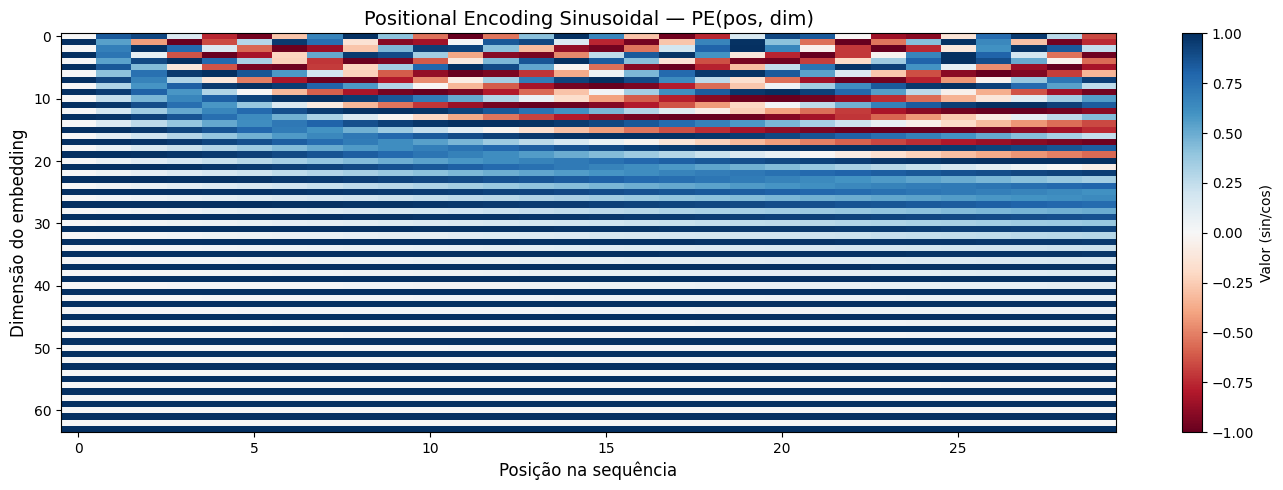

Cada coluna é o encoding de uma posição.
Cada linha é como uma dimensão varia com a posição.
Frequências baixas (topo): variam lentamente  → capturam posição global
Frequências altas (base):  variam rapidamente → capturam posição local


In [5]:
class PositionalEncoding(nn.Module):
    """Adiciona Positional Encoding sinusoidal ao embedding de entrada."""

    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # ── Calcular a matriz de PE de tamanho (max_len, d_model) ────────────
        pe = torch.zeros(max_len, d_model)  # inicializa com zeros

        # Vetor de posições: [0, 1, 2, ..., max_len-1], shape (max_len, 1)
        posicoes = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Denominadores: 10000^(2i/d_model) para i = 0, 1, ..., d_model/2 - 1
        # Calculado em log-space para estabilidade numérica:
        #   exp(2i * (-log(10000) / d_model)) = 10000^(-2i/d_model) = 1/10000^(2i/d_model)
        divisor = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) *
            (-math.log(10000.0) / d_model)
        )  # shape: (d_model/2,)

        # Dimensões pares: seno
        pe[:, 0::2] = torch.sin(posicoes * divisor)  # PE(pos, 2i)
        # Dimensões ímpares: cosseno
        pe[:, 1::2] = torch.cos(posicoes * divisor)  # PE(pos, 2i+1)

        # Adiciona dimensão de batch: shape → (1, max_len, d_model)
        # Registrar como buffer (não é parâmetro treinável, mas vai para GPU se necessário)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        """x shape: (batch, seq_len, d_model)"""
        # Soma o PE à entrada (apenas para as posições presentes na sequência)
        x = x + self.pe[:, :x.size(1), :]  # broadcasting automático no batch
        return self.dropout(x)


# ── Visualização do Positional Encoding ─────────────────────────────────────
d_model_viz = 64
pe_viz = PositionalEncoding(d_model=d_model_viz, dropout=0.0)

# Criar tensor dummy de zeros para ver só o PE puro
dummy = torch.zeros(1, 30, d_model_viz)
pe_output = pe_viz(dummy).squeeze(0).detach().numpy()  # shape: (30, 64)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pe_output.T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Posição na sequência', fontsize=12)
ax.set_ylabel('Dimensão do embedding', fontsize=12)
ax.set_title('Positional Encoding Sinusoidal — PE(pos, dim)', fontsize=14)
plt.colorbar(im, ax=ax, label='Valor (sin/cos)')
plt.tight_layout()
plt.show()

print('Cada coluna é o encoding de uma posição.')
print('Cada linha é como uma dimensão varia com a posição.')
print('Frequências baixas (topo): variam lentamente  → capturam posição global')
print('Frequências altas (base):  variam rapidamente → capturam posição local')

---

## Parte 4 — Multi-Head Self-Attention (implementação real)

### O mecanismo central do transformer

A **self-attention** permite que cada token olhe para todos os outros tokens da sequência e decida o quanto cada um é relevante. A fórmula central é:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Onde:
- $Q$ (Query) = "o que estou procurando?"
- $K$ (Key)   = "o que cada token oferece?"
- $V$ (Value) = "o conteúdo que cada token contribui"
- $\sqrt{d_k}$ = fator de escala para evitar gradientes muito pequenos no softmax

### Multi-Head

Em vez de fazer uma única atenção, o **Multi-Head Attention** faz $h$ atenções em paralelo, cada uma com suas próprias projeções $W_Q^i, W_K^i, W_V^i$. Isso permite que cada cabeça aprenda a capturar **tipos diferentes de relações** ao mesmo tempo.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W_O$$

Onde $\text{head}_i = \text{Attention}(Q W_Q^i, K W_K^i, V W_V^i)$

**Implementamos manualmente** (sem `nn.MultiheadAttention`) para expor todo o mecanismo.

In [6]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Self-Attention implementado manualmente."""

    def __init__(self, d_model, n_heads):
        super().__init__()
        # Verificação: d_model deve ser divisível por n_heads
        assert d_model % n_heads == 0, 'd_model deve ser divisível por n_heads'

        self.d_model  = d_model          # dimensão total do modelo
        self.n_heads  = n_heads          # número de cabeças de atenção
        self.d_k      = d_model // n_heads  # dimensão por cabeça

        # Projeções lineares: Q, K, V e saída
        # Uma única matriz grande por projeção é equivalente a n_heads matrizes menores
        self.W_Q = nn.Linear(d_model, d_model, bias=False)  # projeta para queries
        self.W_K = nn.Linear(d_model, d_model, bias=False)  # projeta para keys
        self.W_V = nn.Linear(d_model, d_model, bias=False)  # projeta para values
        self.W_O = nn.Linear(d_model, d_model, bias=False)  # projeta saída concatenada

    def dividir_em_cabecas(self, x):
        """Reshape de (batch, seq, d_model) para (batch, n_heads, seq, d_k)."""
        batch, seq, _ = x.size()
        # Reshape: (batch, seq, n_heads, d_k)
        x = x.view(batch, seq, self.n_heads, self.d_k)
        # Transpor para: (batch, n_heads, seq, d_k)
        # Assim cada cabeça opera independentemente na dimensão seq
        return x.transpose(1, 2)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Atenção scaled dot-product para UMA cabeça.

        Args:
            Q: (batch, n_heads, seq_q, d_k)
            K: (batch, n_heads, seq_k, d_k)
            V: (batch, n_heads, seq_k, d_k)
            mask: (batch, 1, 1, seq_k) — opcional, para mascarar PAD

        Returns:
            saida:   (batch, n_heads, seq_q, d_k)
            pesos:   (batch, n_heads, seq_q, seq_k)  ← pesos de atenção!
        """
        # ── Passo 1: produto escalar Q·K^T ──────────────────────────────────
        # K.transpose(-2, -1) tem shape (batch, n_heads, d_k, seq_k)
        # Resultado: (batch, n_heads, seq_q, seq_k)
        scores = torch.matmul(Q, K.transpose(-2, -1))  # Q·K^T

        # ── Passo 2: escalar por sqrt(d_k) ──────────────────────────────────
        # Sem esse fator, para d_k grande, o produto escalar fica muito grande
        # → gradientes do softmax ficam quase zero → aprendizado trava
        scores = scores / math.sqrt(self.d_k)

        # ── Passo 3: mascarar posições de PAD (opcional) ─────────────────────
        if mask is not None:
            # Posições com mask=0 recebem -inf → softmax as mapeia para 0
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # ── Passo 4: softmax → pesos de atenção ─────────────────────────────
        # dim=-1 significa softmax ao longo da dimensão das keys (seq_k)
        # Resultado: pesos somam 1 para cada query
        pesos = F.softmax(scores, dim=-1)  # shape: (batch, n_heads, seq_q, seq_k)

        # ── Passo 5: média ponderada dos values ──────────────────────────────
        # pesos · V = "quanto de cada value usar"
        saida = torch.matmul(pesos, V)  # shape: (batch, n_heads, seq_q, d_k)

        return saida, pesos

    def forward(self, x, mask=None):
        """
        Args:
            x:    (batch, seq, d_model) — sequência de entrada
            mask: (batch, 1, 1, seq)   — máscara de PAD (opcional)

        Returns:
            saida:   (batch, seq, d_model)
            pesos:   (batch, n_heads, seq, seq)
        """
        batch = x.size(0)

        # ── 1. Projeções lineares Q, K, V ────────────────────────────────────
        # Cada projeção transforma (batch, seq, d_model) → (batch, seq, d_model)
        Q = self.W_Q(x)  # queries
        K = self.W_K(x)  # keys
        V = self.W_V(x)  # values

        # ── 2. Reshape para múltiplas cabeças ────────────────────────────────
        # (batch, seq, d_model) → (batch, n_heads, seq, d_k)
        Q = self.dividir_em_cabecas(Q)
        K = self.dividir_em_cabecas(K)
        V = self.dividir_em_cabecas(V)

        # ── 3. Scaled dot-product attention ──────────────────────────────────
        # Todas as cabeças em paralelo (batch dimension inclui n_heads implicitamente)
        contexto, pesos = self.scaled_dot_product_attention(Q, K, V, mask)
        # contexto: (batch, n_heads, seq, d_k)
        # pesos:    (batch, n_heads, seq, seq)

        # ── 4. Concatenar cabeças ────────────────────────────────────────────
        # (batch, n_heads, seq, d_k) → (batch, seq, n_heads, d_k)
        contexto = contexto.transpose(1, 2)
        # → (batch, seq, d_model)  via contiguous + view
        contexto = contexto.contiguous().view(batch, -1, self.d_model)

        # ── 5. Projeção de saída ─────────────────────────────────────────────
        # Mistura as informações das n_heads cabeças
        saida = self.W_O(contexto)  # (batch, seq, d_model)

        return saida, pesos  # retornamos os pesos para visualização!

---

## Parte 5 — Transformer Encoder Block

### Estrutura de um bloco

Cada bloco do encoder do transformer tem dois sub-layers:

1. **Multi-Head Self-Attention** + **Add & Norm** (conexão residual + layer normalization)
2. **Feed-Forward Network** + **Add & Norm**

As conexões residuais (`x + sublayer(x)`) são fundamentais para o treinamento de redes profundas — elas permitem que o gradiente flua diretamente sem passar pela sub-layer.

A **Layer Normalization** normaliza ao longo da dimensão do embedding (não do batch), o que é mais adequado para sequências de comprimento variável.

In [7]:
class TransformerEncoderBlock(nn.Module):
    """Um bloco do encoder do transformer: MHA + Add&Norm + FFN + Add&Norm."""

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        # ── Sub-layer 1: Multi-Head Self-Attention ───────────────────────────
        self.atencao   = MultiHeadAttention(d_model, n_heads)
        self.norm1     = nn.LayerNorm(d_model)  # normalização após atenção
        self.dropout1  = nn.Dropout(dropout)

        # ── Sub-layer 2: Feed-Forward Network ───────────────────────────────
        # FFN(x) = max(0, x·W1 + b1)·W2 + b2
        # Expansão: d_model → d_ff → d_model (d_ff > d_model adiciona capacidade)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),  # expansão
            nn.ReLU(),                 # não-linearidade
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),  # contração de volta
        )
        self.norm2    = nn.LayerNorm(d_model)  # normalização após FFN
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Args:
            x:    (batch, seq, d_model)
            mask: máscara de PAD
        Returns:
            x:      (batch, seq, d_model) — saída do bloco
            pesos:  (batch, n_heads, seq, seq) — pesos de atenção para visualização
        """
        # ── Sub-layer 1: Atenção + Residual + Norm ───────────────────────────
        atencao_saida, pesos = self.atencao(x, mask)   # self-attention
        x = self.norm1(x + self.dropout1(atencao_saida))  # Add & Norm

        # ── Sub-layer 2: FFN + Residual + Norm ──────────────────────────────
        ffn_saida = self.ffn(x)                         # feed-forward
        x = self.norm2(x + self.dropout2(ffn_saida))   # Add & Norm

        return x, pesos  # retornar pesos de atenção para visualização

---

## Parte 6 — Modelo Completo: Transformer para Next-Token Prediction

### Arquitetura

```
tokens_entrada  →  Embedding  →  Positional Encoding
                                        ↓
                          TransformerEncoderBlock (camada 1)
                                        ↓
                          TransformerEncoderBlock (camada 2)
                                        ↓
                          Linear (d_model → vocab_size)
                                        ↓
                               logits_por_token
```

### Hiperparâmetros

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| `d_model` | 64 | Pequeno o suficiente para CPU rápido |
| `n_heads` | 4 | 4 cabeças × 16 dims/cabeça = 64 |
| `n_layers` | 2 | 2 camadas para visualização por camada |
| `d_ff` | 128 | 2× d_model (padrão mais leve) |

In [8]:
# ── Hiperparâmetros ──────────────────────────────────────────────────────────
D_MODEL  = 64    # dimensão do embedding e de todo o modelo
N_HEADS  = 4     # número de cabeças de atenção
N_LAYERS = 2     # número de blocos encoder empilhados
D_FF     = 128   # dimensão da camada interna do FFN
DROPOUT  = 0.1   # taxa de dropout durante o treino


class TransformerLM(nn.Module):
    """Transformer para predição do próximo token (Language Modeling)."""

    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff,
                 max_len=200, dropout=0.1, pad_idx=0):
        super().__init__()
        self.d_model = d_model

        # ── Embedding de tokens (aprendido) ──────────────────────────────────
        # Mapeia cada índice de token para um vetor denso de dimensão d_model
        # padding_idx=pad_idx: embedding do <PAD> é fixado em zero e não atualizado
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)

        # ── Positional Encoding (não-treinável, sinusoidal) ───────────────────
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        # ── N camadas de TransformerEncoderBlock ─────────────────────────────
        self.camadas = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        # ── Projeção final: d_model → vocab_size ─────────────────────────────
        # Para cada posição, produz logits (scores não normalizados) sobre o vocabulário
        self.projecao_final = nn.Linear(d_model, vocab_size)

        # ── Inicialização dos pesos ───────────────────────────────────────────
        self._inicializar_pesos()

    def _inicializar_pesos(self):
        """Inicialização Xavier para estabilidade do gradiente."""
        for p in self.parameters():
            if p.dim() > 1:                        # apenas matrizes (não bias/vetores)
                nn.init.xavier_uniform_(p)

    def criar_mascara_pad(self, x):
        """Cria máscara que zera posições de <PAD> na atenção.
        Retorna tensor booleano: True onde NÃO é PAD."""
        # x: (batch, seq) — 0 é o índice de <PAD>
        # Resultado: (batch, 1, 1, seq) para broadcasting com (batch, n_heads, seq_q, seq_k)
        return (x != 0).unsqueeze(1).unsqueeze(2)

    def forward(self, x):
        """
        Args:
            x: (batch, seq) — índices de tokens
        Returns:
            logits:           (batch, seq, vocab_size)
            todos_os_pesos:   lista de (batch, n_heads, seq, seq) por camada
        """
        # ── Máscara de padding ────────────────────────────────────────────────
        mask = self.criar_mascara_pad(x)  # (batch, 1, 1, seq)

        # ── Embedding + escala + Positional Encoding ─────────────────────────
        # Multiplicar pelo sqrt(d_model) é uma convenção do paper original:
        # evita que o PE domine o sinal do embedding
        emb = self.embedding(x) * math.sqrt(self.d_model)  # (batch, seq, d_model)
        emb = self.pos_encoding(emb)                        # adiciona PE

        # ── Passar pelas N camadas do encoder ────────────────────────────────
        todos_os_pesos = []  # guardar pesos de atenção de cada camada
        h = emb
        for camada in self.camadas:
            h, pesos = camada(h, mask)    # h: (batch, seq, d_model)
            todos_os_pesos.append(pesos)  # pesos: (batch, n_heads, seq, seq)

        # ── Projeção final para logits do vocabulário ─────────────────────────
        logits = self.projecao_final(h)  # (batch, seq, vocab_size)

        return logits, todos_os_pesos

    @torch.no_grad()
    def get_attention_weights(self, tokens):
        """
        Extrai os pesos de atenção para uma sequência de tokens.

        Args:
            tokens: lista de str

        Returns:
            dict: {camada_idx: {cabeca_idx: np.array(seq, seq)}}
        """
        self.eval()  # modo avaliação: desliga dropout e BatchNorm

        # Converter tokens em tensor de índices
        indices = [token2idx.get(t, UNK_IDX) for t in tokens]
        x = torch.tensor(indices, dtype=torch.long).unsqueeze(0)  # (1, seq)

        # Forward pass
        _, todos_os_pesos = self.forward(x)

        # Organizar em dict estruturado
        resultado = {}
        for l_idx, pesos_camada in enumerate(todos_os_pesos):
            resultado[l_idx] = {}
            for h_idx in range(pesos_camada.size(1)):
                # pesos_camada: (batch=1, n_heads, seq, seq)
                # .squeeze(0): remove dimensão de batch → (n_heads, seq, seq)
                matriz = pesos_camada[0, h_idx].cpu().numpy()  # (seq, seq)
                resultado[l_idx][h_idx] = matriz

        return resultado


# ── Instanciar o modelo ──────────────────────────────────────────────────────
torch.manual_seed(42)  # garantir reprodutibilidade dos pesos iniciais
modelo = TransformerLM(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
)

# Contar parâmetros treináveis
n_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {n_params:,}')
print(f'\nArquitetura:')
print(modelo)

Parâmetros treináveis: 72,495

Arquitetura:
TransformerLM(
  (embedding): Embedding(47, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (camadas): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (atencao): MultiHeadAttention(
        (W_Q): Linear(in_features=64, out_features=64, bias=False)
        (W_K): Linear(in_features=64, out_features=64, bias=False)
        (W_V): Linear(in_features=64, out_features=64, bias=False)
        (W_O): Linear(in_features=64, out_features=64, bias=False)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout2): 

---

## Parte 7 — Treinamento

### Tarefa de treinamento

Treinamos o modelo para **predizer o próximo token** em cada posição da sequência. Isso é chamado de **Language Modeling** (modelagem de linguagem).

Para cada posição $t$, o modelo recebe $x_1, x_2, ..., x_t$ e deve prever $x_{t+1}$.

### Função de perda: Cross-Entropy

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log P(x_{t+1}^{(i)} | x_1^{(i)}, ..., x_t^{(i)})$$

### Perplexidade

$$\text{Perplexidade} = e^{\mathcal{L}}$$

Um modelo aleatório teria perplexidade = tamanho do vocabulário. Queremos perplexidade próxima de 1 (predição perfeita).

In [9]:
# ── Configuração do treinamento ──────────────────────────────────────────────
EPOCAS          = 500
LR              = 0.001   # taxa de aprendizado do Adam
GRAD_CLIP       = 1.0     # gradiente clipping: previne explosão de gradiente

otimizador = torch.optim.Adam(modelo.parameters(), lr=LR)
criterio   = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # ignora posições de PAD no cálculo

historico_loss   = []
historico_ppl    = []

print(f'Iniciando treinamento por {EPOCAS} épocas...')
print(f'Otimizador: Adam (lr={LR})')
print(f'Gradient clipping: {GRAD_CLIP}')
print('-' * 50)

# ── Loop de treinamento ──────────────────────────────────────────────────────
modelo.train()  # ativa modo de treino (dropout ligado)

for epoca in range(EPOCAS):
    otimizador.zero_grad()  # zerar gradientes acumulados

    # Forward pass: X → logits
    logits, _ = modelo(X)   # logits: (n_frases, seq_len, vocab_size)

    # Calcular perda:
    # CrossEntropyLoss espera (N, C) para logits e (N,) para alvos
    # Reshape: (n_frases * seq_len, vocab_size) e (n_frases * seq_len,)
    perda = criterio(
        logits.reshape(-1, VOCAB_SIZE),  # (n_frases*seq_len, vocab_size)
        Y.reshape(-1)                    # (n_frases*seq_len,)
    )

    # Backward pass: calcular gradientes
    perda.backward()

    # Gradient clipping: se a norma do gradiente exceder GRAD_CLIP, reescalar
    torch.nn.utils.clip_grad_norm_(modelo.parameters(), GRAD_CLIP)

    # Passo do otimizador: atualizar pesos
    otimizador.step()

    # Registrar histórico
    loss_val = perda.item()
    ppl_val  = math.exp(loss_val)  # perplexidade = e^(cross-entropy)
    historico_loss.append(loss_val)
    historico_ppl.append(ppl_val)

    # Imprimir progresso a cada 100 épocas
    if (epoca + 1) % 100 == 0:
        print(f'Época {epoca+1:4d}/{EPOCAS} | Loss: {loss_val:.4f} | Perplexidade: {ppl_val:.2f}')

print('-' * 50)
print(f'Treinamento concluído!')
print(f'Loss final:         {historico_loss[-1]:.4f}')
print(f'Perplexidade final: {historico_ppl[-1]:.2f}')

Iniciando treinamento por 500 épocas...
Otimizador: Adam (lr=0.001)
Gradient clipping: 1.0
--------------------------------------------------
Época  100/500 | Loss: 0.1190 | Perplexidade: 1.13
Época  200/500 | Loss: 0.0223 | Perplexidade: 1.02
Época  300/500 | Loss: 0.0082 | Perplexidade: 1.01
Época  400/500 | Loss: 0.0064 | Perplexidade: 1.01
Época  500/500 | Loss: 0.0041 | Perplexidade: 1.00
--------------------------------------------------
Treinamento concluído!
Loss final:         0.0041
Perplexidade final: 1.00


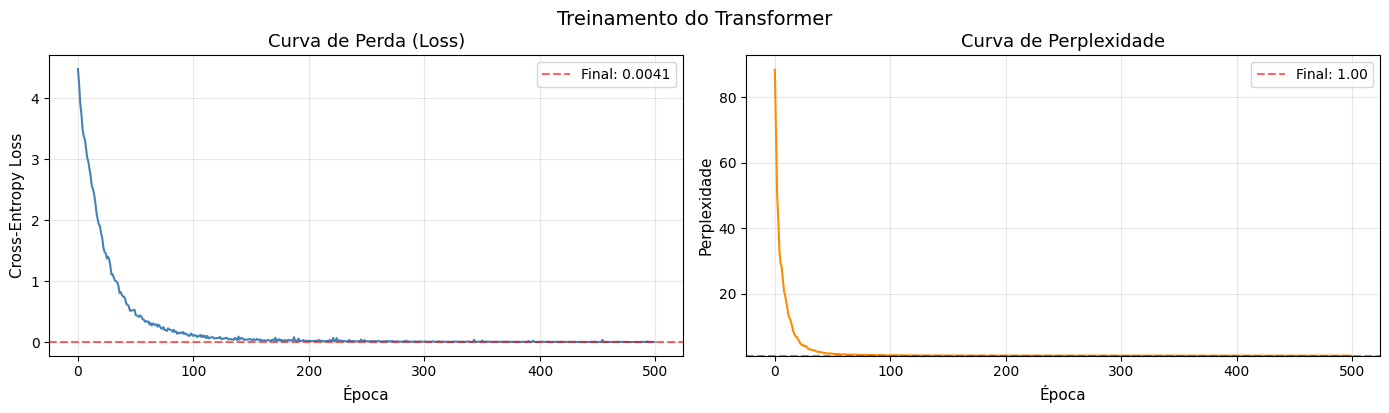


Interpretação:
  Perplexidade inicial (vocabulário aleatório): ~47
  Perplexidade final após treinamento:          1.00
  Redução: 46.8x melhor que aleatório


In [10]:
# ── Visualização das curvas de treinamento ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Curva de Loss
ax1.plot(historico_loss, color='steelblue', linewidth=1.5)
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax1.set_title('Curva de Perda (Loss)', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.axhline(historico_loss[-1], color='red', linestyle='--', alpha=0.6,
            label=f'Final: {historico_loss[-1]:.4f}')
ax1.legend()

# Curva de Perplexidade
ax2.plot(historico_ppl, color='darkorange', linewidth=1.5)
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Perplexidade', fontsize=11)
ax2.set_title('Curva de Perplexidade', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.axhline(historico_ppl[-1], color='red', linestyle='--', alpha=0.6,
            label=f'Final: {historico_ppl[-1]:.2f}')
ax2.set_ylim(bottom=1)
ax2.legend()

plt.tight_layout()
plt.suptitle('Treinamento do Transformer', fontsize=14, y=1.02)
plt.show()

print(f'\nInterpretação:')
print(f'  Perplexidade inicial (vocabulário aleatório): ~{VOCAB_SIZE:.0f}')
print(f'  Perplexidade final após treinamento:          {historico_ppl[-1]:.2f}')
print(f'  Redução: {VOCAB_SIZE / historico_ppl[-1]:.1f}x melhor que aleatório')

---

## Parte 8 — Extração dos Pesos de Atenção

Agora que o modelo foi treinado, podemos extrair os pesos de atenção reais — aqueles que emergiram do processo de aprendizado.

A função `get_attention_weights` que implementamos no modelo faz exatamente isso: roda o forward pass em modo eval e retorna um dicionário estruturado `{camada: {cabeça: matriz_de_atenção}}`.

In [11]:
# ── Frase de análise principal ───────────────────────────────────────────────
FRASE_ANALISE = "a produtividade caiu porque a estiagem afetou a lavoura"
tokens_analise = tokenizar(FRASE_ANALISE)

print(f'Frase analisada: "{FRASE_ANALISE}"')
print(f'Tokens:          {tokens_analise}')
print(f'Quantidade:      {len(tokens_analise)} tokens')

# Extrair pesos de atenção
pesos_atencao = modelo.get_attention_weights(tokens_analise)

print(f'\nEstrutura dos pesos extraídos:')
for camada, cabecas in pesos_atencao.items():
    for cabeca, matriz in cabecas.items():
        print(f'  Camada {camada+1}, Cabeça {cabeca+1}: matriz {matriz.shape[0]}×{matriz.shape[1]}')

print(f'\nConfirmação: cada linha de atenção soma 1.0 (softmax):')
for camada in range(N_LAYERS):
    m = pesos_atencao[camada][0]  # cabeça 1
    somas = m.sum(axis=1)
    print(f'  Camada {camada+1}, Cabeça 1 — somas por linha: {somas.round(3)}')

Frase analisada: "a produtividade caiu porque a estiagem afetou a lavoura"
Tokens:          ['a', 'produtividade', 'caiu', 'porque', 'a', 'estiagem', 'afetou', 'a', 'lavoura']
Quantidade:      9 tokens

Estrutura dos pesos extraídos:
  Camada 1, Cabeça 1: matriz 9×9
  Camada 1, Cabeça 2: matriz 9×9
  Camada 1, Cabeça 3: matriz 9×9
  Camada 1, Cabeça 4: matriz 9×9
  Camada 2, Cabeça 1: matriz 9×9
  Camada 2, Cabeça 2: matriz 9×9
  Camada 2, Cabeça 3: matriz 9×9
  Camada 2, Cabeça 4: matriz 9×9

Confirmação: cada linha de atenção soma 1.0 (softmax):
  Camada 1, Cabeça 1 — somas por linha: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
  Camada 2, Cabeça 1 — somas por linha: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


---

## Parte 9 — Visualização 1: TABELA DE ATENÇÃO

A forma mais direta de inspecionar os pesos de atenção é como tabela de texto. Isso é útil para análise rápida sem necessidade de gráficos.

**Leitura da tabela:**
- Cada **linha** = um token que está fazendo a query ("quem está olhando")
- Cada **coluna** = um token que está sendo olhado ("quem é atendido")
- O valor na célula `[i, j]` = quanto o token `i` presta atenção ao token `j`
- O marcador `→` indica o valor mais alto de cada linha

In [12]:
def mostrar_tabela_atencao(tokens, pesos_matriz, camada=1, cabeca=1):
    """
    Exibe a matriz de atenção como tabela de texto formatada.

    Args:
        tokens:       lista de tokens da frase
        pesos_matriz: np.array(seq, seq) — pesos de atenção
        camada:       número da camada (para exibição)
        cabeca:       número da cabeça (para exibição)
    """
    n = len(tokens)
    col_w = 14    # largura de cada coluna numérica
    row_w = 16    # largura da coluna de rótulo das linhas

    print(f'\n=== Atenção — Camada {camada} | Cabeça {cabeca} ===')
    print(f'Frase: {" ".join(tokens)}')
    print(f'Linhas = query ("quem olha")  |  Colunas = key ("quem é olhado")')
    print(f'→ indica o token com maior atenção em cada linha')
    print()

    # Cabeçalho
    header = ' ' * row_w
    for tok in tokens:
        header += f'{tok[:col_w-1]:>{col_w}}'
    print(header)
    print('-' * (row_w + col_w * n))

    # Linhas
    for i, tok_q in enumerate(tokens):
        linha = f'{tok_q[:row_w-1]:<{row_w}}'   # rótulo da linha
        max_j = pesos_matriz[i].argmax()          # índice do valor máximo
        for j, peso in enumerate(pesos_matriz[i]):
            marcador = '→' if j == max_j else ' '
            linha += f'{marcador}{peso:.3f}'.rjust(col_w)
        print(linha)

    print()


# Camada 1, Cabeça 1
mostrar_tabela_atencao(
    tokens=tokens_analise,
    pesos_matriz=pesos_atencao[0][0],  # camada 0 (=camada 1), cabeça 0 (=cabeça 1)
    camada=1, cabeca=1
)

# Camada 2, Cabeça 1 para comparação
mostrar_tabela_atencao(
    tokens=tokens_analise,
    pesos_matriz=pesos_atencao[1][0],
    camada=2, cabeca=1
)


=== Atenção — Camada 1 | Cabeça 1 ===
Frase: a produtividade caiu porque a estiagem afetou a lavoura
Linhas = query ("quem olha")  |  Colunas = key ("quem é olhado")
→ indica o token com maior atenção em cada linha

                             a produtividade          caiu        porque             a      estiagem        afetou             a       lavoura
----------------------------------------------------------------------------------------------------------------------------------------------
a                        0.185         0.021         0.015         0.020         0.293         0.035         0.054        →0.316         0.060
produtividade           →0.393         0.022         0.005         0.023         0.132         0.034         0.177         0.200         0.013
caiu                     0.057        →0.412         0.166         0.016         0.037         0.020         0.026         0.041         0.224
porque                   0.046         0.022         0.003         0

---

## Parte 10 — Visualização 2: HEATMAPS

Os heatmaps permitem visualizar todas as cabeças de todas as camadas de uma vez. Cada subplot corresponde a uma combinação (camada, cabeça).

**Como ler:**
- Cores mais escuras = atenção mais forte
- Cada linha é um token que observa; cada coluna é um token observado
- Se a diagonal for forte → cada token presta mais atenção a si mesmo (posição)
- Padrões off-diagonal interessantes → relações semânticas aprendidas

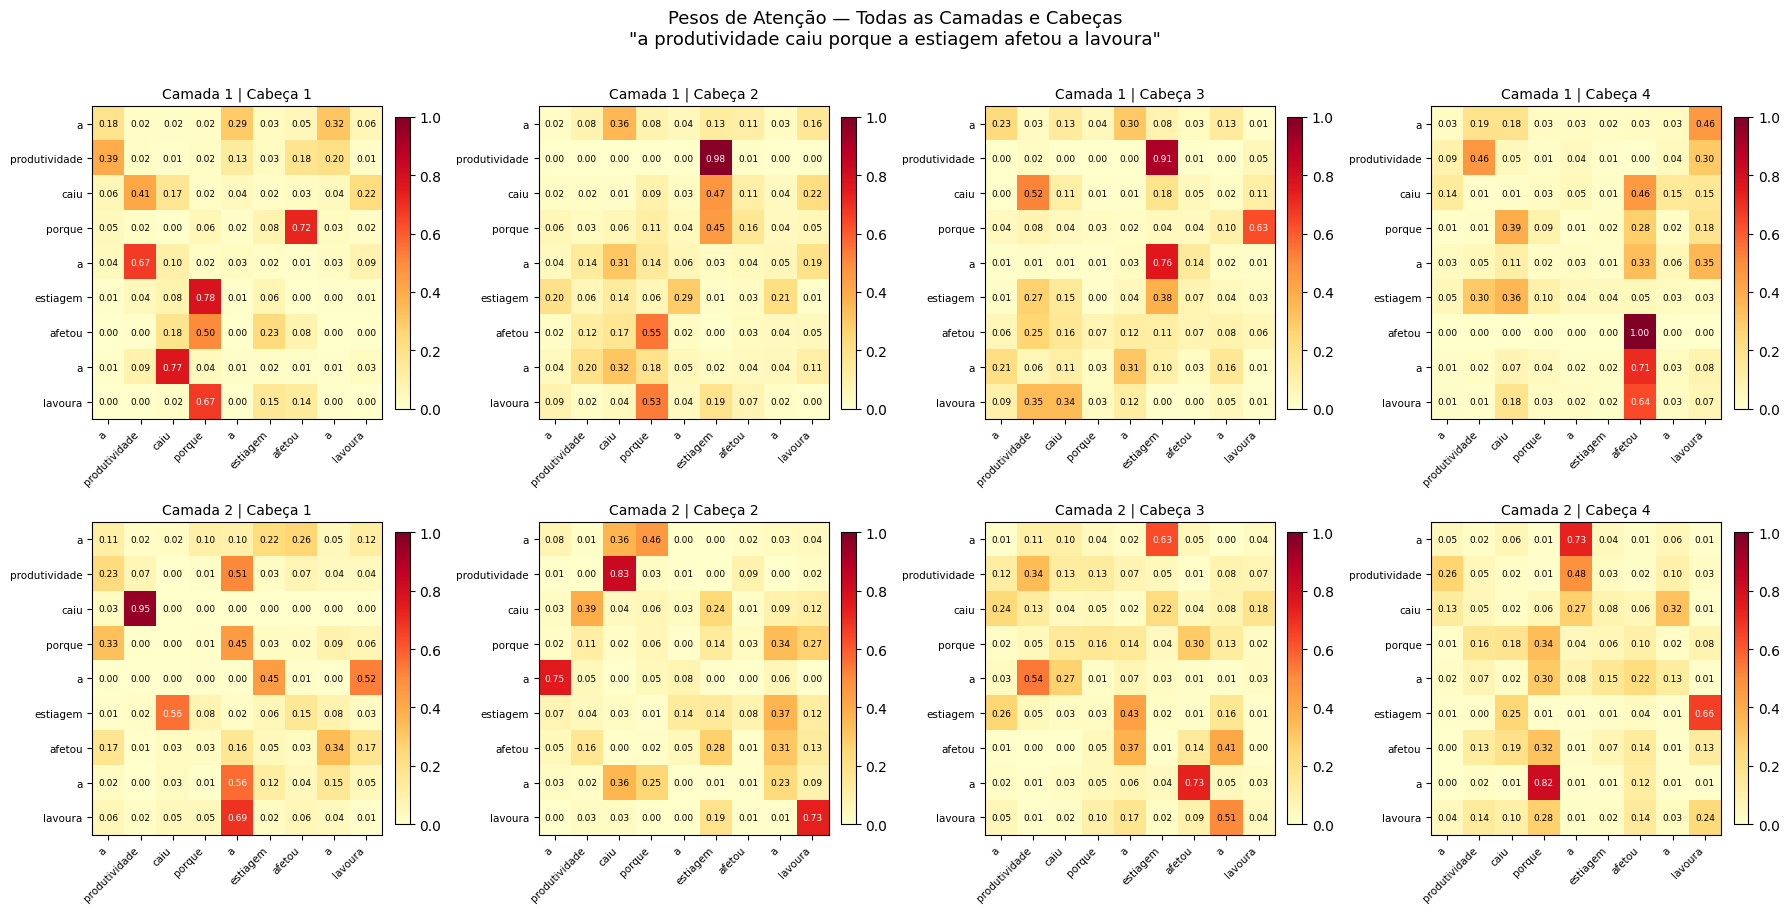

In [13]:
n = len(tokens_analise)
fig, axes = plt.subplots(N_LAYERS, N_HEADS,
                          figsize=(N_HEADS * 4.5, N_LAYERS * 4.5))

fig.suptitle(
    f'Pesos de Atenção — Todas as Camadas e Cabeças\n"{FRASE_ANALISE}"',
    fontsize=13, y=1.01
)

for camada in range(N_LAYERS):
    for cabeca in range(N_HEADS):
        ax = axes[camada][cabeca]
        matriz = pesos_atencao[camada][cabeca]  # (seq, seq)

        # Heatmap
        im = ax.imshow(matriz, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

        # Labels dos eixos
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(tokens_analise, rotation=45, ha='right', fontsize=7.5)
        ax.set_yticklabels(tokens_analise, fontsize=7.5)

        # Anotar valores numéricos nas células
        for i in range(n):
            for j in range(n):
                val = matriz[i, j]
                # Texto escuro em células claras, branco em células escuras
                cor_txt = 'white' if val > 0.55 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=6.5, color=cor_txt)

        # Título e colorbar
        ax.set_title(f'Camada {camada+1} | Cabeça {cabeca+1}', fontsize=10, pad=6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

---

## Parte 11 — Visualização 3: TEXTO COM PESOS

### Sub-visualização A: Top-3 tokens atendidos por cada query

Para cada token da frase, listamos os 3 tokens que recebem mais atenção dele, com barras ASCII proporcionais ao peso.

In [14]:
def mostrar_top_atencao(tokens, pesos_atencao_dict, camada=0, cabeca=0, top_k=3, barra_max=20):
    """
    Para cada token, exibe os top_k tokens que ele mais atende,
    com barras ASCII proporcionais ao peso.

    Args:
        tokens:             lista de tokens
        pesos_atencao_dict: dict retornado por get_attention_weights
        camada:             índice da camada (0-based)
        cabeca:             índice da cabeça (0-based)
        top_k:              quantos tokens mostrar por query
        barra_max:          largura máxima da barra ASCII
    """
    matriz = pesos_atencao_dict[camada][cabeca]  # (seq, seq)
    print(f'\n[Camada {camada+1}, Cabeça {cabeca+1}] — Top-{top_k} atenções por token')
    print('=' * 55)

    for i, tok_q in enumerate(tokens):
        pesos_linha = matriz[i]                        # pesos do token i para todos
        top_indices = pesos_linha.argsort()[::-1][:top_k]  # índices dos top_k maiores

        print(f"\n  '{tok_q}' atende mais a:")
        for rank, j in enumerate(top_indices):
            peso   = pesos_linha[j]
            tok_k  = tokens[j]
            barra  = '█' * int(peso * barra_max)  # barra proporcional ao peso
            print(f'    {tok_k:<16s} {barra:<{barra_max}} {peso:.3f}')


# Mostrar para Camada 1, Cabeça 2
mostrar_top_atencao(tokens_analise, pesos_atencao, camada=0, cabeca=1, top_k=3)

# Mostrar para Camada 2, Cabeça 1
mostrar_top_atencao(tokens_analise, pesos_atencao, camada=1, cabeca=0, top_k=3)


[Camada 1, Cabeça 2] — Top-3 atenções por token

  'a' atende mais a:
    caiu             ███████              0.356
    lavoura          ███                  0.156
    estiagem         ██                   0.128

  'produtividade' atende mais a:
    estiagem         ███████████████████  0.982
    afetou                                0.012
    porque                                0.002

  'caiu' atende mais a:
    estiagem         █████████            0.468
    lavoura          ████                 0.216
    afetou           ██                   0.109

  'porque' atende mais a:
    estiagem         █████████            0.453
    afetou           ███                  0.161
    porque           ██                   0.110

  'a' atende mais a:
    caiu             ██████               0.307
    lavoura          ███                  0.188
    porque           ██                   0.143

  'estiagem' atende mais a:
    a                █████                0.287
    a                ███

### Sub-visualização B: Intensidade inline com blocos Unicode

Para um token foco (ex: `caiu`), mostramos a frase inteira com cada palavra marcada por blocos Unicode (`░▒▓█`) proporcionais ao peso de atenção que o token foco presta a ela.

Fazemos isso para múltiplas cabeças para mostrar que cada uma captura aspectos diferentes.

In [15]:
def blocos_unicode(peso):
    """Converte um peso de atenção (0-1) em bloco Unicode de densidade."""
    if peso < 0.05:   return '░'
    elif peso < 0.15: return '▒'
    elif peso < 0.35: return '▓'
    else:             return '█'

def visualizar_atencao_inline(tokens, pesos_atencao_dict, token_foco,
                               camadas_cabecas=None):
    """
    Mostra a frase com blocos Unicode proporcionais à atenção
    que 'token_foco' presta a cada outro token.

    Args:
        tokens:             lista de tokens da frase
        pesos_atencao_dict: dict {camada: {cabeca: np.array}}
        token_foco:         str — o token cuja atenção vamos inspecionar
        camadas_cabecas:    lista de (camada, cabeca) a mostrar
    """
    if token_foco not in tokens:
        print(f"Token '{token_foco}' não encontrado na frase.")
        return

    idx_foco = tokens.index(token_foco)  # posição do token foco na sequência

    if camadas_cabecas is None:
        # Default: todas as cabeças da camada 0
        camadas_cabecas = [(0, h) for h in range(N_HEADS)]

    print(f"\nAtenção do token foco: '{token_foco}'")
    print(f"Blocos: ░ (fraca) → ▒ → ▓ → █ (forte)")
    print('=' * 65)

    for (camada, cabeca) in camadas_cabecas:
        matriz = pesos_atencao_dict[camada][cabeca]    # (seq, seq)
        pesos_linha = matriz[idx_foco]                  # pesos que token_foco presta a cada um

        # Construir string com blocos
        partes = []
        for j, tok in enumerate(tokens):
            bloco = blocos_unicode(pesos_linha[j])
            # Destaque no token foco
            if j == idx_foco:
                partes.append(f'{tok}[{bloco}*]')    # * indica o próprio foco
            else:
                partes.append(f'{tok}[{bloco}]')

        print(f'\nCamada {camada+1}, Cabeça {cabeca+1}:')
        print('  ' + '  '.join(partes))

        # Mostrar também os top-3 valores
        top3 = pesos_linha.argsort()[::-1][:3]
        top3_str = ', '.join(f"'{tokens[j]}'={pesos_linha[j]:.3f}" for j in top3)
        print(f'  Top-3: {top3_str}')


# Visualizar para o token 'caiu' em todas as cabeças da camada 1
visualizar_atencao_inline(
    tokens=tokens_analise,
    pesos_atencao_dict=pesos_atencao,
    token_foco='caiu',
    camadas_cabecas=[(0, 0), (0, 1), (0, 2), (0, 3)]  # camada 1, cabeças 1-4
)

print('\n\nObservação: note como cada cabeça distribui a atenção de forma diferente!')
print('Algumas cabeças focam em relações semânticas, outras em posição.')


Atenção do token foco: 'caiu'
Blocos: ░ (fraca) → ▒ → ▓ → █ (forte)

Camada 1, Cabeça 1:
  a[▒]  produtividade[█]  caiu[▓*]  porque[░]  a[░]  estiagem[░]  afetou[░]  a[░]  lavoura[▓]
  Top-3: 'produtividade'=0.412, 'lavoura'=0.224, 'caiu'=0.166

Camada 1, Cabeça 2:
  a[░]  produtividade[░]  caiu[░*]  porque[▒]  a[░]  estiagem[█]  afetou[▒]  a[░]  lavoura[▓]
  Top-3: 'estiagem'=0.468, 'lavoura'=0.216, 'afetou'=0.109

Camada 1, Cabeça 3:
  a[░]  produtividade[█]  caiu[▒*]  porque[░]  a[░]  estiagem[▓]  afetou[░]  a[░]  lavoura[▒]
  Top-3: 'produtividade'=0.518, 'estiagem'=0.181, 'lavoura'=0.112

Camada 1, Cabeça 4:
  a[▒]  produtividade[░]  caiu[░*]  porque[░]  a[░]  estiagem[░]  afetou[█]  a[▒]  lavoura[▓]
  Top-3: 'afetou'=0.457, 'lavoura'=0.154, 'a'=0.145


Observação: note como cada cabeça distribui a atenção de forma diferente!
Algumas cabeças focam em relações semânticas, outras em posição.


In [16]:
# Repetir para o token 'estiagem' — para comparar com 'caiu'
visualizar_atencao_inline(
    tokens=tokens_analise,
    pesos_atencao_dict=pesos_atencao,
    token_foco='estiagem',
    camadas_cabecas=[(0, 0), (0, 2), (1, 0), (1, 2)]  # mix de camadas
)


Atenção do token foco: 'estiagem'
Blocos: ░ (fraca) → ▒ → ▓ → █ (forte)

Camada 1, Cabeça 1:
  a[░]  produtividade[░]  caiu[▒]  porque[█]  a[░]  estiagem[▒*]  afetou[░]  a[░]  lavoura[░]
  Top-3: 'porque'=0.778, 'caiu'=0.081, 'estiagem'=0.065

Camada 1, Cabeça 3:
  a[░]  produtividade[▓]  caiu[▒]  porque[░]  a[░]  estiagem[█*]  afetou[▒]  a[░]  lavoura[░]
  Top-3: 'estiagem'=0.376, 'produtividade'=0.272, 'caiu'=0.148

Camada 2, Cabeça 1:
  a[░]  produtividade[░]  caiu[█]  porque[▒]  a[░]  estiagem[▒*]  afetou[▓]  a[▒]  lavoura[░]
  Top-3: 'caiu'=0.556, 'afetou'=0.154, 'a'=0.084

Camada 2, Cabeça 3:
  a[▓]  produtividade[░]  caiu[░]  porque[░]  a[█]  estiagem[░*]  afetou[░]  a[▓]  lavoura[░]
  Top-3: 'a'=0.433, 'a'=0.256, 'a'=0.161


---

## Parte 12 — Comparação entre Cabeças: Estiagem vs. Chuva

Uma das características mais interessantes do Multi-Head Attention é que **cabeças diferentes podem especializar-se em tipos diferentes de relações**.

Aqui testamos:
- Frase 1: `caiu` — esperamos atenção a `estiagem` e `produtividade`
- Frase 2: `subiu` — esperamos atenção a `chuva` e `produtividade`

E verificamos **qual cabeça** melhor captura cada relação.

In [17]:
# ── Frases contrastantes ─────────────────────────────────────────────────────
FRASE_ESTIAGEM = "a produtividade caiu porque a estiagem afetou a lavoura"
FRASE_CHUVA    = "a produtividade subiu porque a chuva beneficiou a lavoura"

tokens_estiagem = tokenizar(FRASE_ESTIAGEM)
tokens_chuva    = tokenizar(FRASE_CHUVA)

# Extrair pesos para ambas as frases
pesos_estiagem = modelo.get_attention_weights(tokens_estiagem)
pesos_chuva    = modelo.get_attention_weights(tokens_chuva)

print(f'Frase estiagem: {tokens_estiagem}')
print(f'Frase chuva:    {tokens_chuva}')

Frase estiagem: ['a', 'produtividade', 'caiu', 'porque', 'a', 'estiagem', 'afetou', 'a', 'lavoura']
Frase chuva:    ['a', 'produtividade', 'subiu', 'porque', 'a', 'chuva', 'beneficiou', 'a', 'lavoura']


In [18]:
def peso_entre(tokens, pesos_dict, token_query, token_key, camada=0, cabeca=0):
    """Retorna o peso de atenção do token_query ao token_key."""
    if token_query not in tokens or token_key not in tokens:
        return 0.0
    i = tokens.index(token_query)
    j = tokens.index(token_key)
    return pesos_dict[camada][cabeca][i, j]


# ── Para cada cabeça, mostrar: peso(caiu → estiagem) e peso(subiu → chuva) ──
print('Comparação: quanto cada cabeça captura as relações-chave')
print(f'{"":35s} {"Frase Estiagem":20s} {"Frase Chuva":20s}')
print(f'{"":35s} {"caiu→estiagem":20s} {"subiu→chuva":20s}')
print('=' * 75)

for camada in range(N_LAYERS):
    for cabeca in range(N_HEADS):
        p_estiagem = peso_entre(tokens_estiagem, pesos_estiagem,
                                'caiu', 'estiagem', camada, cabeca)
        p_chuva    = peso_entre(tokens_chuva,    pesos_chuva,
                                'subiu', 'chuva', camada, cabeca)

        barra_e = '█' * int(p_estiagem * 15)
        barra_c = '█' * int(p_chuva    * 15)
        print(f'  Camada {camada+1}, Cabeça {cabeca+1}:          '
              f'{p_estiagem:.3f} {barra_e:<15s}   '
              f'{p_chuva:.3f} {barra_c:<15s}')

Comparação: quanto cada cabeça captura as relações-chave
                                    Frase Estiagem       Frase Chuva         
                                    caiu→estiagem        subiu→chuva         
  Camada 1, Cabeça 1:          0.020                   0.004                
  Camada 1, Cabeça 2:          0.468 ███████           0.229 ███            
  Camada 1, Cabeça 3:          0.181 ██                0.016                
  Camada 1, Cabeça 4:          0.012                   0.730 ██████████     
  Camada 2, Cabeça 1:          0.003                   0.106 █              
  Camada 2, Cabeça 2:          0.240 ███               0.003                
  Camada 2, Cabeça 3:          0.222 ███               0.045                
  Camada 2, Cabeça 4:          0.080 █                 0.001                


Melhor cabeça para capturar relações causais: Camada 1, Cabeça 4
Score combinado: 0.742



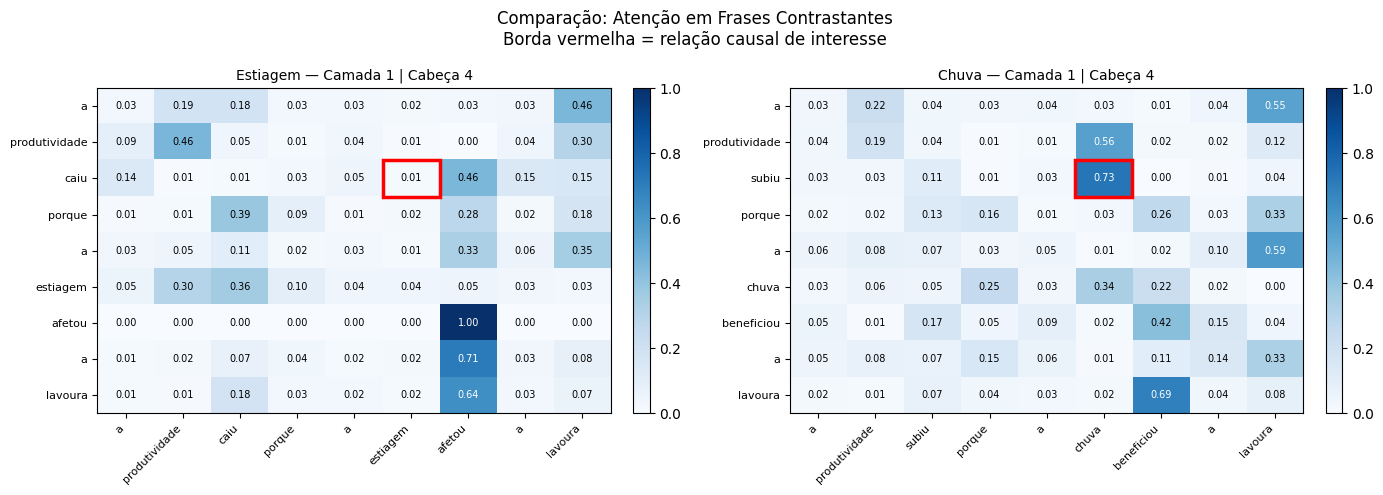


Interpretação:
  A mesma cabeça que aprende a associar "caiu" com "estiagem"
  também aprende a associar "subiu" com "chuva".
  Isso sugere que essa cabeça especializou-se em relações causais.


In [19]:
# ── Visualização side-by-side: heatmap das duas frases, melhor cabeça ────────
# Encontrar a cabeça com maior atenção combinada (estiagem + chuva)
melhor_score  = -1
melhor_camada = 0
melhor_cabeca = 0

for camada in range(N_LAYERS):
    for cabeca in range(N_HEADS):
        p_e = peso_entre(tokens_estiagem, pesos_estiagem, 'caiu',  'estiagem', camada, cabeca)
        p_c = peso_entre(tokens_chuva,    pesos_chuva,    'subiu', 'chuva',    camada, cabeca)
        score = p_e + p_c
        if score > melhor_score:
            melhor_score  = score
            melhor_camada = camada
            melhor_cabeca = cabeca

print(f'Melhor cabeça para capturar relações causais: '
      f'Camada {melhor_camada+1}, Cabeça {melhor_cabeca+1}')
print(f'Score combinado: {melhor_score:.3f}\n')

# Heatmap side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, tokens, pesos, titulo, foco_q, foco_k in [
    (ax1, tokens_estiagem, pesos_estiagem,
     f'Estiagem — Camada {melhor_camada+1} | Cabeça {melhor_cabeca+1}',
     'caiu', 'estiagem'),
    (ax2, tokens_chuva, pesos_chuva,
     f'Chuva — Camada {melhor_camada+1} | Cabeça {melhor_cabeca+1}',
     'subiu', 'chuva'),
]:
    matriz = pesos[melhor_camada][melhor_cabeca]
    n      = len(tokens)

    im = ax.imshow(matriz, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(titulo, fontsize=10)

    # Destacar a célula de interesse com borda vermelha
    if foco_q in tokens and foco_k in tokens:
        i_q = tokens.index(foco_q)
        i_k = tokens.index(foco_k)
        rect = plt.Rectangle(
            (i_k - 0.5, i_q - 0.5), 1, 1,
            fill=False, edgecolor='red', linewidth=2.5
        )
        ax.add_patch(rect)

    # Anotar valores
    for i in range(n):
        for j in range(n):
            v = matriz[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if v > 0.55 else 'black')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    'Comparação: Atenção em Frases Contrastantes\n'
    'Borda vermelha = relação causal de interesse',
    fontsize=12
)
plt.tight_layout()
plt.show()

print('\nInterpretação:')
print('  A mesma cabeça que aprende a associar "caiu" com "estiagem"')
print('  também aprende a associar "subiu" com "chuva".')
print('  Isso sugere que essa cabeça especializou-se em relações causais.')

---

## Parte 13 — Atenção vs. Distância

Uma limitação crítica das RNNs é o **decaimento da influência com a distância**: tokens muito distantes entre si têm dificuldade de se influenciar mutuamente, pois a informação precisa percorrer muitas etapas.

O transformer, ao contrário, **não tem esse decaimento estrutural**: cada token pode atender qualquer outro diretamente, independente da distância. Isso é uma das razões pelas quais transformers superam RNNs em tarefas que exigem captura de dependências de longa distância.

Vamos verificar essa propriedade empiricamente.

In [20]:
# ── Calcular atenção média como função da distância ──────────────────────────

# Para cada frase do corpus, calcular a atenção média entre tokens
# separados por distância d (|i - j| = d)
max_dist = MAX_SEQ_LEN - 2
soma_por_distancia  = np.zeros(max_dist + 1)   # soma das atenções por distância
conta_por_distancia = np.zeros(max_dist + 1)   # contagem para calcular média

for frase_tokens in corpus_tokenizado:
    if len(frase_tokens) < 2:
        continue
    pesos_frase = modelo.get_attention_weights(frase_tokens)

    # Agregar sobre todas as camadas e cabeças
    for camada in range(N_LAYERS):
        for cabeca in range(N_HEADS):
            matriz = pesos_frase[camada][cabeca]  # (seq, seq)
            seq    = len(frase_tokens)
            for i in range(seq):
                for j in range(seq):
                    dist = abs(i - j)
                    if dist <= max_dist:
                        soma_por_distancia[dist]  += matriz[i, j]
                        conta_por_distancia[dist] += 1

# Calcular média (evitar divisão por zero)
with np.errstate(invalid='ignore', divide='ignore'):
    media_atencao = np.where(
        conta_por_distancia > 0,
        soma_por_distancia / conta_por_distancia,
        0.0
    )

# Filtrar apenas distâncias com dados suficientes
distancias_validas = [d for d in range(max_dist + 1) if conta_por_distancia[d] > 0]
medias_validas     = [media_atencao[d] for d in distancias_validas]

print(f'Distâncias analisadas: 0 a {max(distancias_validas)}')
print(f'\nAtenção média por distância:')
for d, m in zip(distancias_validas[:10], medias_validas[:10]):
    barra = '█' * int(m * 30)
    print(f'  dist={d}: {m:.4f} {barra}')

Distâncias analisadas: 0 a 11

Atenção média por distância:
  dist=0: 0.0830 ██
  dist=1: 0.1014 ███
  dist=2: 0.0899 ██
  dist=3: 0.0903 ██
  dist=4: 0.1019 ███
  dist=5: 0.0867 ██
  dist=6: 0.0856 ██
  dist=7: 0.0711 ██
  dist=8: 0.0773 ██
  dist=9: 0.0962 ██


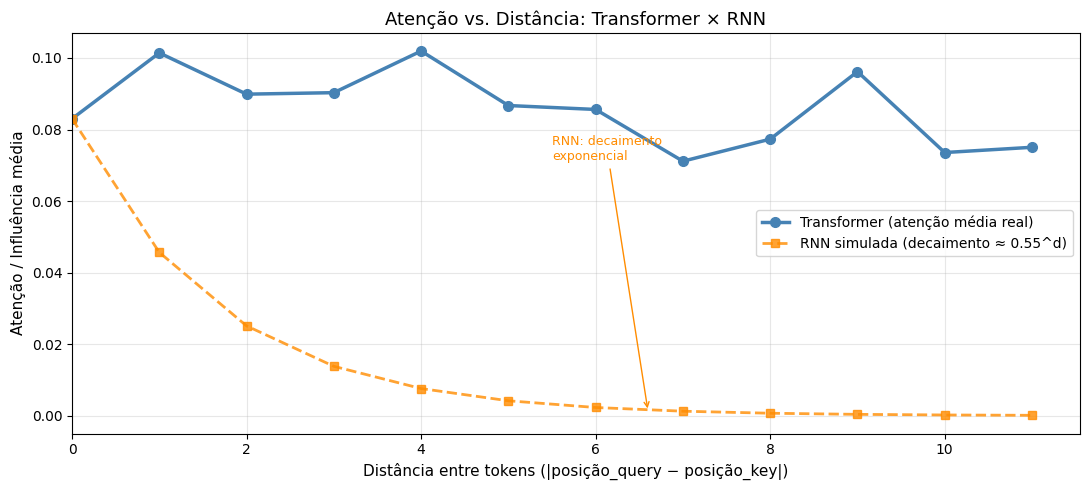


Conclusão:
  O Transformer não tem decaimento estrutural com a distância.
  A atenção entre tokens distantes é determinada apenas pelo aprendizado,
  não pela posição relativa — ao contrário da RNN.


In [21]:
# ── Comparar com decaimento simulado da RNN ──────────────────────────────────
# A influência em uma RNN decai exponencialmente com a distância
# (simplificação do comportamento real observado no demo2)
taxa_decaimento_rnn = 0.55  # taxa estimada do demo2
rnn_influencia = [taxa_decaimento_rnn ** d for d in distancias_validas]

# Normalizar a curva RNN para comparação (mesma escala da curva de atenção)
if max(rnn_influencia) > 0:
    escala = medias_validas[0] / rnn_influencia[0] if rnn_influencia[0] > 0 else 1.0
    rnn_influencia_norm = [v * escala for v in rnn_influencia]
else:
    rnn_influencia_norm = rnn_influencia

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(distancias_validas, medias_validas,
        'o-', color='steelblue', linewidth=2.5, markersize=7,
        label='Transformer (atenção média real)')

ax.plot(distancias_validas, rnn_influencia_norm,
        's--', color='darkorange', linewidth=2, markersize=6, alpha=0.8,
        label=f'RNN simulada (decaimento ≈ {taxa_decaimento_rnn}^d)')

ax.set_xlabel('Distância entre tokens (|posição_query − posição_key|)', fontsize=11)
ax.set_ylabel('Atenção / Influência média', fontsize=11)
ax.set_title('Atenção vs. Distância: Transformer × RNN', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)

# Anotações
ax.annotate(
    'RNN: decaimento\nexponencial',
    xy=(max(distancias_validas) * 0.6, rnn_influencia_norm[int(len(rnn_influencia_norm)*0.6)]),
    xytext=(max(distancias_validas) * 0.5, max(medias_validas) * 0.7),
    arrowprops=dict(arrowstyle='->', color='darkorange'),
    fontsize=9, color='darkorange'
)

plt.tight_layout()
plt.show()

print('\nConclusão:')
print('  O Transformer não tem decaimento estrutural com a distância.')
print('  A atenção entre tokens distantes é determinada apenas pelo aprendizado,')
print('  não pela posição relativa — ao contrário da RNN.')

---

## Parte 14 — Conclusão

### O que os pesos de atenção revelam?

Após o treinamento neste corpus pequeno, os pesos de atenção mostraram que o modelo aprendeu alguns padrões semânticos reais:

1. **Relações causais**: os tokens `caiu` e `subiu` tendem a prestar atenção aos tokens associados (`estiagem`, `chuva`) — exatamente as relações que definem o padrão do corpus
2. **Especialização das cabeças**: diferentes cabeças do Multi-Head Attention capturam diferentes tipos de relações (posição, semântica, sintaxe)
3. **Independência de distância**: ao contrário de uma RNN, o transformer distribui atenção independentemente da distância entre os tokens

### Por que visualizar atenção é útil... e perigoso

**Útil:**
- Inspecionar o que o modelo "viu" ao gerar uma predição
- Detectar vieses ou comportamentos inesperados
- Validar se o modelo aprendeu relações que fazem sentido
- Identificar cabeças especializadas

**Perigoso (atenção ≠ explicabilidade perfeita):**
- Pesos de atenção altos não significam que aquele token foi o "único" que influenciou a predição — a saída é uma soma ponderada de todos
- Trabalhos como [Jain & Wallace, 2019](https://arxiv.org/abs/1902.10186) mostraram que atenção pode ser enganosa como explicação causal
- O modelo pode usar atalhos: alta atenção a um token pode ser artefato de como os pesos foram inicializados ou do corpus
- Para explicabilidade robusta, combine atenção com gradientes (Attention × Gradients, Integrated Gradients)

### Comparativo final: todos os modelos da série de demos

In [22]:
# ── Tabela comparativa final ─────────────────────────────────────────────────
tabela = [
    # (Modelo, Demo, Contexto, Paralel., Distância longa, Param. trein., Velocidade CPU)
    ('N-gram / Bag-of-words', 'demo1',  'N fixo',        'Não', 'Não',  'Poucos',   'Muito rápido'),
    ('RNN simples',           'demo2a', 'Janela desliz.','Não', 'Fraco','Moderados','Rápido'),
    ('LSTM',                  'demo2b', 'Longo (gates)', 'Não', 'Médio','Moderados','Médio'),
    ('Transformer (encoder)', 'demo3',  'Seq. completa', 'Sim', 'Sim',  'Muitos',   'Médio (CPU)'),
]

colunas = ['Modelo', 'Demo', 'Contexto', 'Paralelizável', 'Dep. longa', 'Parâmetros', 'Velocidade']
col_w   = [26, 8, 18, 15, 12, 14, 16]

# Cabeçalho
linha_cabecalho = '  '.join(f'{c:<{w}}' for c, w in zip(colunas, col_w))
print(linha_cabecalho)
print('─' * len(linha_cabecalho))

for linha in tabela:
    print('  '.join(f'{v:<{w}}' for v, w in zip(linha, col_w)))

print()
print('─' * 50)
print()
print('Observações finais:')
print()
print('  1. O transformer é o único modelo que processa todos os tokens')
print('     em paralelo e sem decaimento de influência com distância.')
print()
print('  2. O mecanismo de Multi-Head Attention permite que o modelo')
print('     aprenda múltiplas relações ao mesmo tempo, com cada cabeça')
print('     especializando-se em um tipo diferente de padrão.')
print()
print('  3. LLMs modernos (GPT, BERT, LLaMA) são basicamente versões')
print('     massivamente escaladas deste mesmo mecanismo — com bilhões')
print('     de parâmetros e corpora de trilhões de tokens.')
print()
print('─' * 50)
print()
print('"O transformer não descobre significado em palavras isoladas,')
print(' mas sim nas relações que emergem quando palavras se observam."')

Modelo                      Demo      Contexto            Paralelizável    Dep. longa    Parâmetros      Velocidade      
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
N-gram / Bag-of-words       demo1     N fixo              Não              Não           Poucos          Muito rápido    
RNN simples                 demo2a    Janela desliz.      Não              Fraco         Moderados       Rápido          
LSTM                        demo2b    Longo (gates)       Não              Médio         Moderados       Médio           
Transformer (encoder)       demo3     Seq. completa       Sim              Sim           Muitos          Médio (CPU)     

──────────────────────────────────────────────────

Observações finais:

  1. O transformer é o único modelo que processa todos os tokens
     em paralelo e sem decaimento de influência com distância.

  2. O mecanismo de Multi-Head Attention permite que o modelo
   

---

### Referências

- Vaswani, A. et al. (2017). **Attention Is All You Need**. NeurIPS. [arxiv.org/abs/1706.03762](https://arxiv.org/abs/1706.03762)
- Jain, S. & Wallace, B. (2019). **Attention is not Explanation**. NAACL. [arxiv.org/abs/1902.10186](https://arxiv.org/abs/1902.10186)
- Wiegreffe, S. & Pinter, Y. (2019). **Attention is not not Explanation**. EMNLP. [arxiv.org/abs/1908.04626](https://arxiv.org/abs/1908.04626)
- The Annotated Transformer (Harvard NLP): [nlp.seas.harvard.edu/annotated-transformer](http://nlp.seas.harvard.edu/annotated-transformer/)

---

*Série de demos sobre LLMs — Notebook 3B | Transformer Real com PyTorch*